In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf

data_dir = "/content/drive/MyDrive/Colab Notebooks/Licenta/lfw"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 3123 files belonging to 64 classes.
Using 2499 files for training.
Found 3123 files belonging to 64 classes.
Using 624 files for validation.


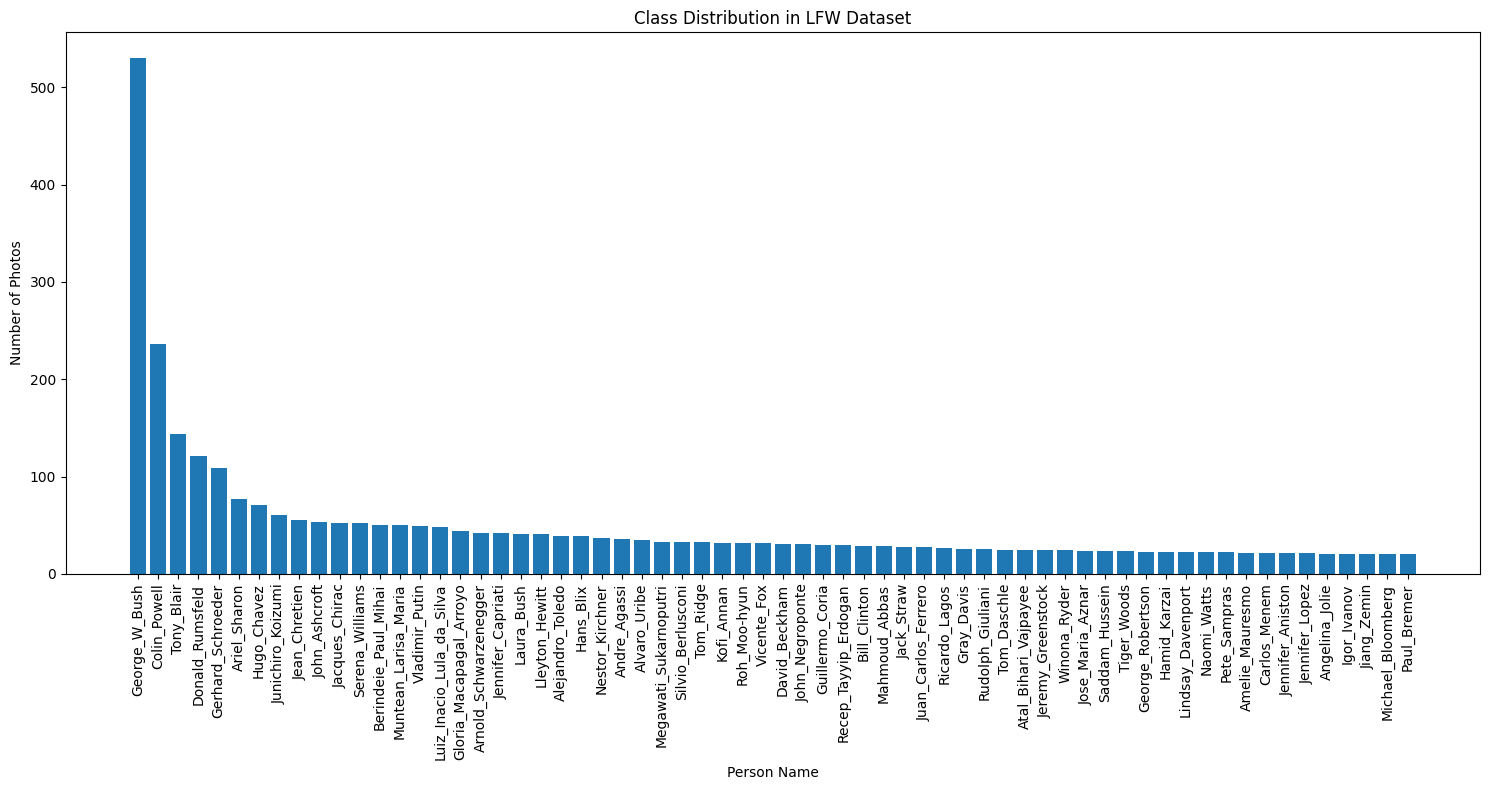

In [3]:

import matplotlib.pyplot as plt
import os

# Count images per class using the stored class_names list
counts = {}
for name in class_names:
    class_path = os.path.join(data_dir, name)
    if os.path.isdir(class_path):
        counts[name] = len(os.listdir(class_path))

# Sort and plot
sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
names = [item[0] for item in sorted_counts]
values = [item[1] for item in sorted_counts]

plt.figure(figsize=(15, 8))
plt.bar(names, values)
plt.xticks(rotation=90)
plt.xlabel('Person Name')
plt.ylabel('Number of Photos')
plt.title('Class Distribution in LFW Dataset')
plt.tight_layout()
plt.show()

In [4]:
import tensorflow as tf

# 1. Normalize data to [0, 1] range
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

print("Datasets normalized successfully.")

Datasets normalized successfully.


In [5]:
# 2. Define the baseline architecture that reached ~0.87 accuracy
num_classes = 62

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
], name='BaselineCNN')

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "BaselineCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,176,958 (42.64 MB)

 Trainable params: 11,176,958 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import os

# 3. Setup Custom Callback for periodic saving
checkpoint_dir = '/content/drive/MyDrive/Colab Notebooks/Licenta/My_arhitecture/Checkpoints'
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

class PeriodicModelCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, checkpoint_dir, interval=5):
        super(PeriodicModelCheckpoint, self).__init__()
        self.checkpoint_dir = checkpoint_dir
        self.interval = interval

    def on_epoch_end(self, epoch, logs=None):
        # epoch is 0-indexed, so epoch 4 is actually the 5th epoch
        current_epoch = epoch + 1
        if current_epoch % self.interval == 0:
            val_acc = logs.get('val_accuracy', 0.0)
            filepath = os.path.join(
                self.checkpoint_dir,
                f'Baseline_epoch_{current_epoch:02d}_acc_{val_acc:.2f}.keras'
            )
            self.model.save(filepath)
            print(f'\nEpoch {current_epoch}: Saving model to {filepath}')

checkpoint_callback = PeriodicModelCheckpoint(checkpoint_dir, interval=5)
callbacks_list = [checkpoint_callback]



In [7]:
# 4. Train the model
epochs = 30
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks_list
)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 570s 7s/step - accuracy: 0.0072 - loss: nan - val_accuracy: 0.0048 - val_loss: nan
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 186ms/step - accuracy: 0.0068 - loss: nan - val_accuracy: 0.0048 - val_loss: nan
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.0068 - loss: nan - val_accuracy: 0.0048 - val_loss: nan
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 229ms/step - accuracy: 0.0068 - loss: nan - val_accuracy: 0.0048 - val_loss: nan
Epoch 5/30
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.0075 - loss: nan
Epoch 5: Saving model to /content/drive/MyDrive/Colab Notebooks/Licenta/My_arhitecture/Checkpoints/Baseline_epoch_05_acc_0.00.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 218ms/step - accuracy: 0.0068 - loss: nan - val_accuracy: 0.0048 - val_loss: nan
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.0068 - loss: nan - val_accuracy: 0.0048 - val_loss: nan
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 192ms/step - accur

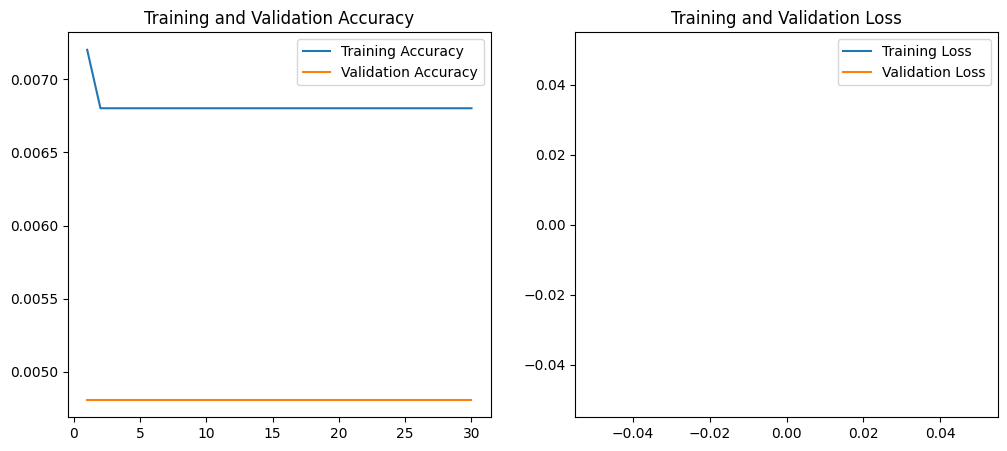

In [8]:
import matplotlib.pyplot as plt

# Restore Training History Plots
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

Detailed Classification Report:
                           precision    recall  f1-score   support

         Alejandro_Toledo       0.02      1.00      0.03        10
             Alvaro_Uribe       0.00      0.00      0.00         7
          Amelie_Mauresmo       0.00      0.00      0.00         5
             Andre_Agassi       0.00      0.00      0.00         7
           Angelina_Jolie       0.00      0.00      0.00         5
             Ariel_Sharon       0.00      0.00      0.00        11
    Arnold_Schwarzenegger       0.00      0.00      0.00        10
     Atal_Bihari_Vajpayee       0.00      0.00      0.00         6
     Berindeie_Paul_Mihai       0.00      0.00      0.00        10
             Bill_Clinton       0.00      0.00      0.00         6
             Carlos_Menem       0.00      0.00      0.00         3
             Colin_Powell       0.00      0.00      0.00        50
            David_Beckham       0.00      0.00      0.00         4
          Donald_Rumsfeld    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


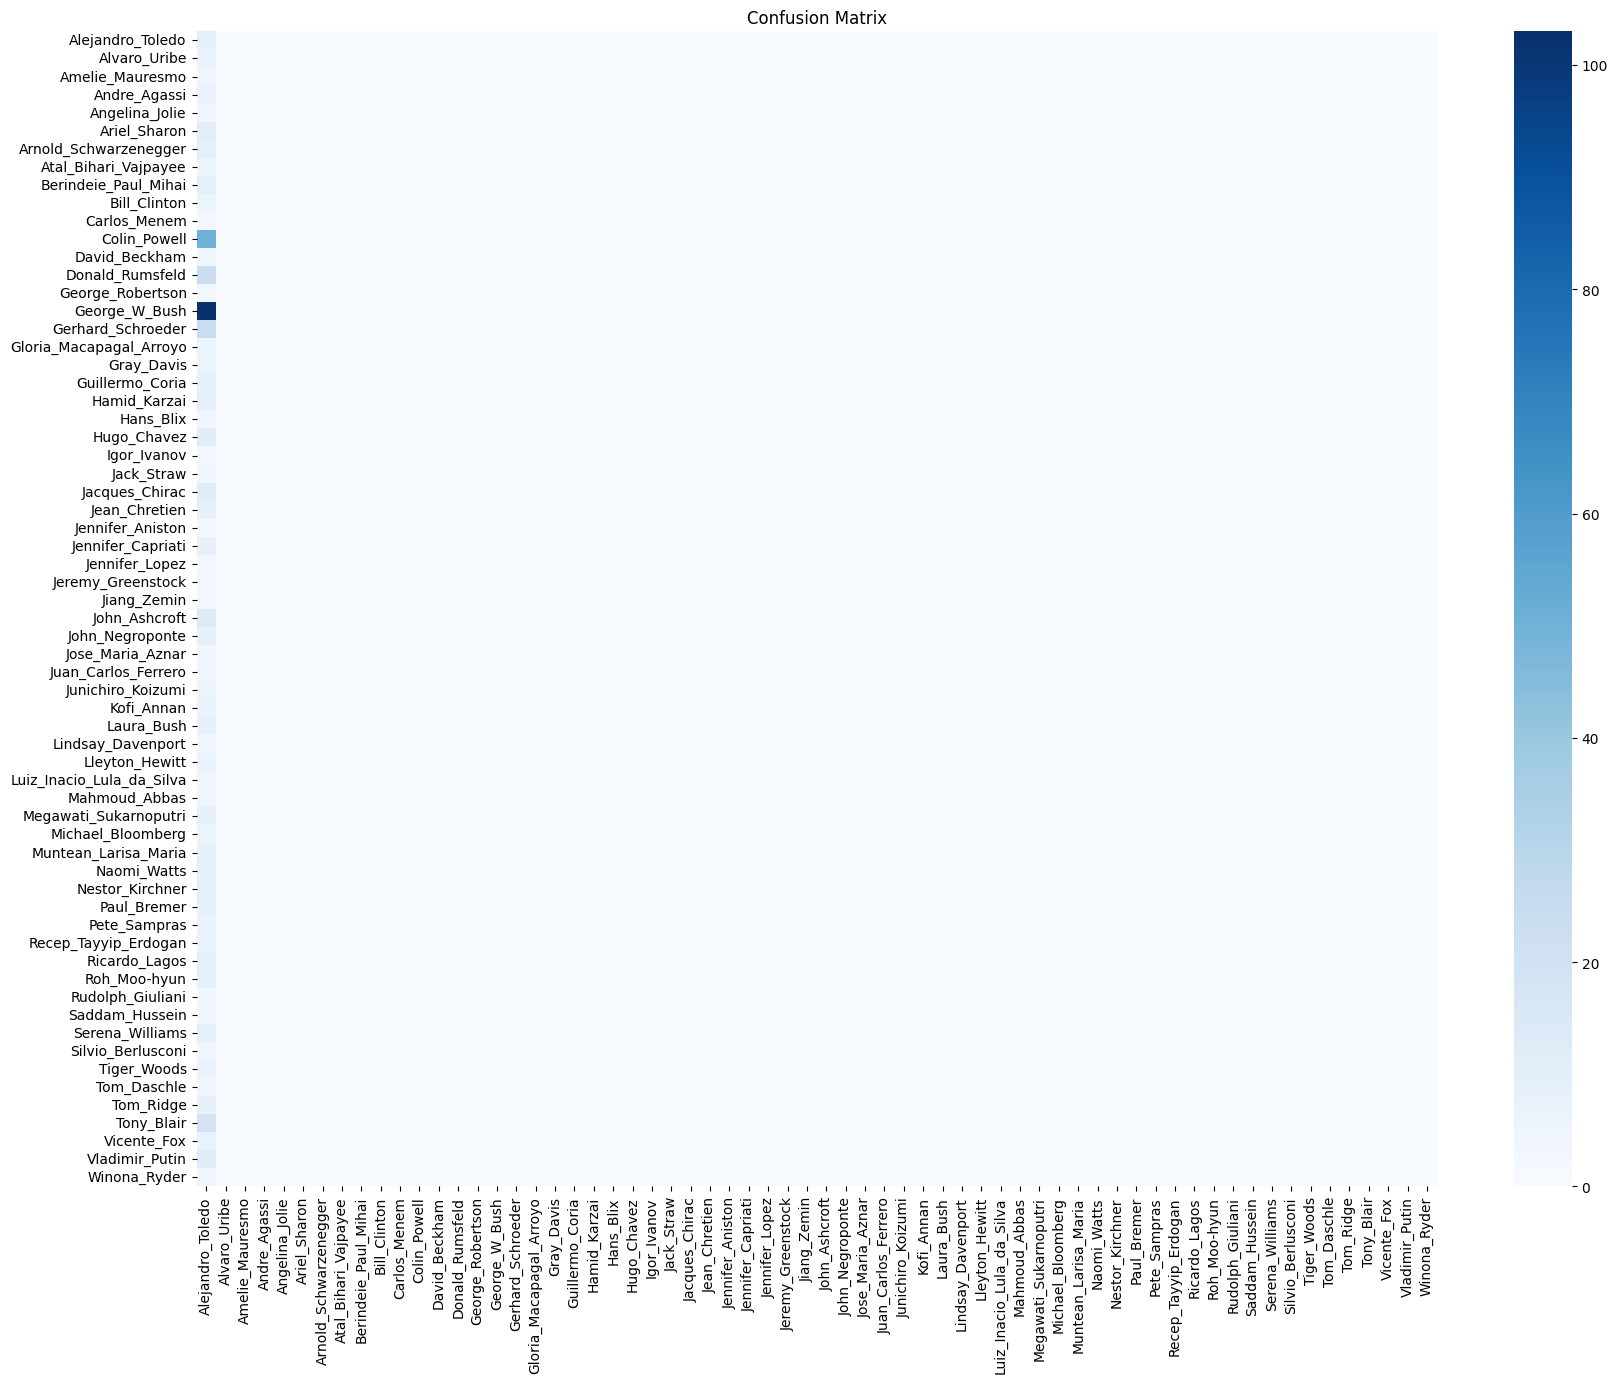

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Get predictions for the validation set
all_labels = []
all_preds = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(np.argmax(preds, axis=1))

# 2. Display Classification Report
print("Detailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 3. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.show()